# Street Vendor Survival Prediction
# Phase 7 - Model Explainability
# Feature Importance and SHAP Analysis

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
dataset_path = (
    r"C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/"
    r"Minor Project/Street-Vendor-Survival-Prediction/"
    r"datasets/processed_dataset/"
    r"street_vendor_survival_feature_engineered.csv")

model_path = (
    r"C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/"
    r"Minor Project/Street-Vendor-Survival-Prediction/"
    r"models/trained_model.pkl")

figure_path = (
    r"C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/"
    r"Minor Project/Street-Vendor-Survival-Prediction/"
    r"reports/figures/Explainability")

os.makedirs(figure_path, exist_ok=True)
print("File paths configured successfully")

File paths configured successfully


In [3]:
df = pd.read_csv(dataset_path)
print("Feature Engineered Dataset Loaded Successfully")
print(f"Dataset Shape: {df.shape}")
df.head()

Feature Engineered Dataset Loaded Successfully
Dataset Shape: (22000, 64)


,vendor_age_years,years_in_business,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,had_fine_last_year,...,revenue_category_Medium,revenue_category_High,revenue_category_Very_High,competition_category_Medium,competition_category_High,inspection_category_Low,inspection_category_Moderate,inspection_category_Good,complaint_category_Moderate,complaint_category_High
0,34.0,10.98,332.20,10.0,0.00,1,10.00,4.0,65.00,0,...,0,0,0,1,0,0,1,0,1,0
1,33.0,5.53,3138.90,180.0,2112.10,1,6.42,3.0,0.00,1,...,0,0,1,0,0,0,0,0,0,1
2,48.0,2.70,1626.36,67.0,5487.75,3,11.80,0.0,0.00,0,...,0,1,0,0,0,0,0,0,0,0
3,37.0,9.77,3592.98,171.0,1960.79,3,12.53,6.0,36.38,1,...,0,0,1,1,0,1,0,0,0,0
4,51.0,21.24,2418.07,105.0,2720.82,4,6.07,5.0,71.05,0,...,0,0,1,1,0,0,1,0,0,0


In [4]:
model = joblib.load(model_path)
print("Trained Model Loaded Successfully")
print(f"Model Type: {type(model).__name__}")

Trained Model Loaded Successfully
Model Type: XGBClassifier


In [5]:
X = df.drop(columns=["vendor_survived"])
y = df["vendor_survived"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (22000, 63)
Target Shape: (22000,)


In [6]:
feature_names = X.columns.tolist()
print("Number of Features:", len(feature_names))
print("\nFirst 10 Features:")
print(feature_names[:10])

Number of Features: 63

First 10 Features:
['vendor_age_years', 'years_in_business', 'avg_daily_revenue_inr', 'avg_daily_customers', 'monthly_stall_rent_inr', 'num_helpers', 'hours_open_per_day', 'competition_within_100m', 'monthly_health_inspection_score', 'had_fine_last_year']


In [7]:
if hasattr(model, "named_steps"):
    print("Saved object is a Pipeline")
    print("Pipeline Steps:")
    print(model.named_steps.keys())
    final_model = model.named_steps["model"]
else:
    print("Saved object is a standalone model")
    final_model = model
print("\nFinal Model Type:", type(final_model).__name__)

Saved object is a standalone model

Final Model Type: XGBClassifier


In [8]:
if hasattr(final_model, "n_features_in_"):
    print("Features expected by model:", final_model.n_features_in_)
    print("Features provided by dataset:", X.shape[1])

    if final_model.n_features_in_ != X.shape[1]:
        raise ValueError("Number of features does not match between the model and dataset.")
print("Feature compatibility check completed")

Features expected by model: 63
Features provided by dataset: 63
Feature compatibility check completed


In [9]:
print("Calculating Feature Importance...")
if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
elif hasattr(final_model, "coef_"):
    importance_values = abs(final_model.coef_[0])
else:
    raise ValueError("The trained model does not provide feature importance.")
print("Feature importance calculated successfully")

Calculating Feature Importance...
Feature importance calculated successfully


In [10]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False).reset_index(drop=True)
importance_df.head(15)

,Feature,Importance
0,revenue_category_Medium,0.077699
1,revenue_category_High,0.075957
2,avg_daily_revenue_inr,0.066798
3,inspection_category_Low,0.029601
4,license_status_Unlicensed,0.029568
5,license_status_Licensed,0.026543
6,license_status_Pending Renewal,0.024866
7,had_fine_last_year,0.023769
8,complaint_category_High,0.020510
9,revenue_category_Very_High,0.016231


In [11]:
print("Top 15 Important Features:\n")
print(
    importance_df
    .head(15)
    .to_string(index=False))

Top 15 Important Features:

                        Feature  Importance
        revenue_category_Medium    0.077699
          revenue_category_High    0.075957
          avg_daily_revenue_inr    0.066798
        inspection_category_Low    0.029601
      license_status_Unlicensed    0.029568
        license_status_Licensed    0.026543
 license_status_Pending Renewal    0.024866
             had_fine_last_year    0.023769
        complaint_category_High    0.020510
     revenue_category_Very_High    0.016231
      estimated_monthly_revenue    0.015558
        customer_complaint_rate    0.015200
            has_online_presence    0.014894
               revenue_per_hour    0.014645
monthly_health_inspection_score    0.014527


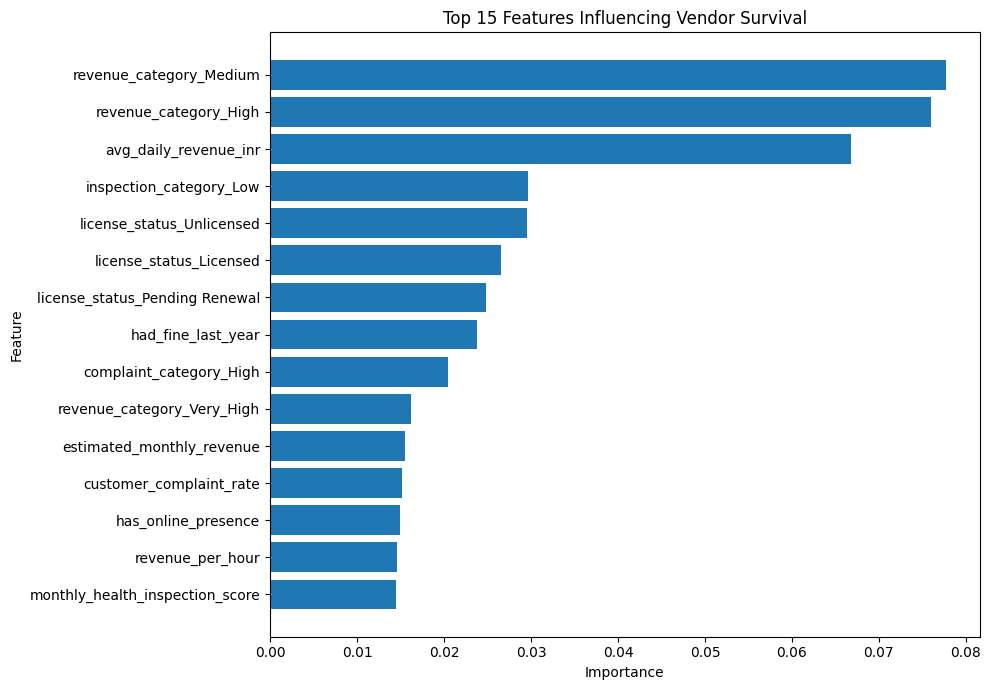

Feature Importance Graph Saved:
C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/Minor Project/Street-Vendor-Survival-Prediction/reports/figures/Explainability\feature_importance.png


In [12]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Vendor Survival")

plt.tight_layout()
importance_file = os.path.join(figure_path, "feature_importance.png")
plt.savefig(
    importance_file,
    dpi=300,
    bbox_inches="tight")

plt.show()
plt.close()
print("Feature Importance Graph Saved:")
print(importance_file)

In [13]:
print("Starting SHAP Analysis...")
if hasattr(final_model, "feature_importances_"):
    explainer = shap.TreeExplainer(final_model)
    print("TreeExplainer created successfully")
else:
    explainer = shap.Explainer(model, X)
    print("General SHAP Explainer created successfully")

Starting SHAP Analysis...
TreeExplainer created successfully


In [14]:
shap_values = explainer.shap_values(X)
print("SHAP values calculated successfully")

SHAP values calculated successfully


In [15]:
if isinstance(shap_values, list):
    print("SHAP returned values for multiple classes")
    shap_values_for_active = shap_values[1]
else:
    shap_values_for_active = shap_values
print("SHAP values prepared for survival analysis")

SHAP values prepared for survival analysis


In [16]:
print("X Shape:", X.shape)
if hasattr(shap_values_for_active, "shape"):
    print("SHAP Shape:", shap_values_for_active.shape)

X Shape: (22000, 63)
SHAP Shape: (22000, 63)


Creating SHAP Summary Plot...


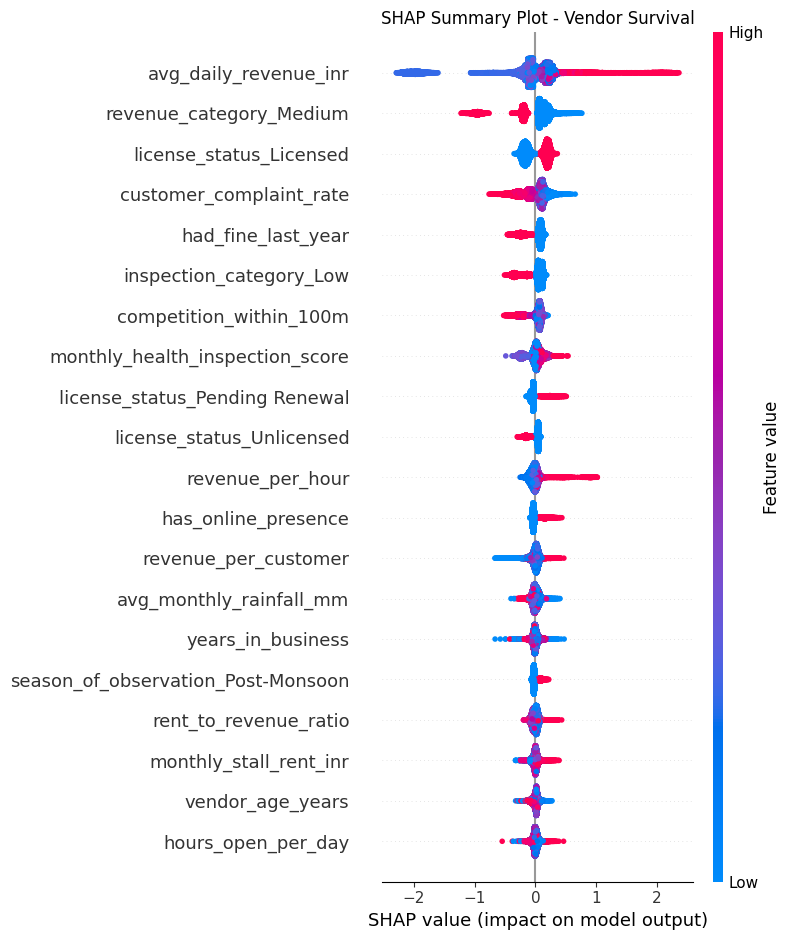

SHAP Summary Graph Saved:
C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/Minor Project/Street-Vendor-Survival-Prediction/reports/figures/Explainability\shap_summary.png


In [17]:
print("Creating SHAP Summary Plot...")
plt.figure()
shap.summary_plot(
    shap_values_for_active,
    X,
    show=False)

plt.title("SHAP Summary Plot - Vendor Survival")
plt.tight_layout()
shap_summary_file = os.path.join(
    figure_path,
    "shap_summary.png")

plt.savefig(
    shap_summary_file,
    dpi=300,
    bbox_inches="tight")

plt.show()
plt.close()
print("SHAP Summary Graph Saved:")
print(shap_summary_file)

Creating SHAP Feature Importance Plot...


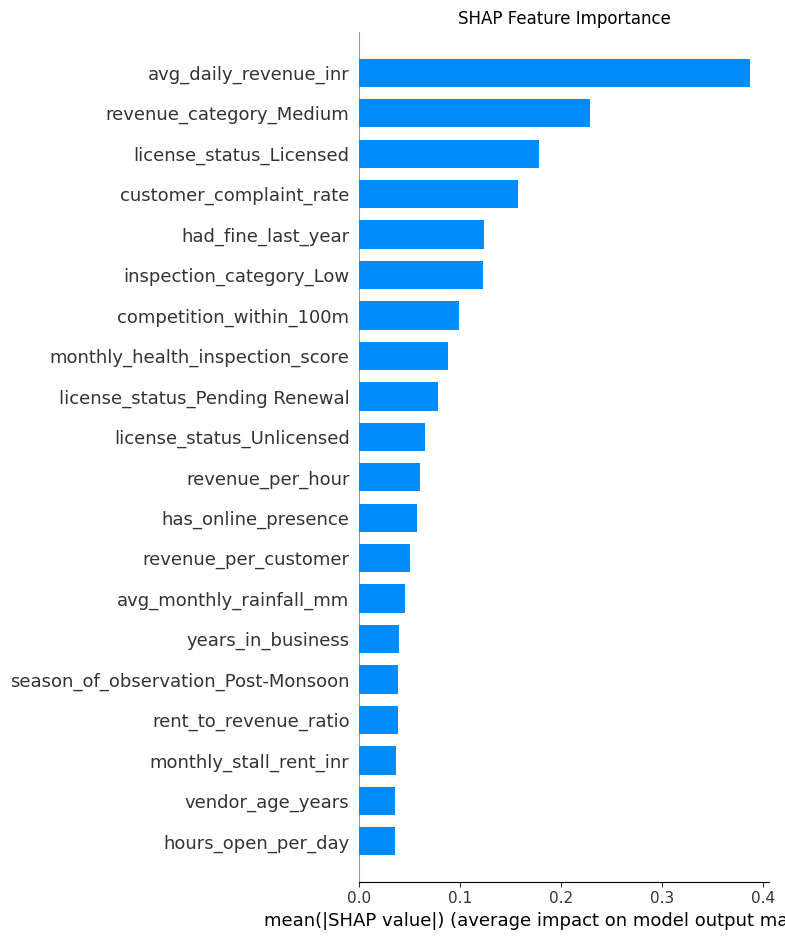

SHAP Bar Graph Saved:
C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/Minor Project/Street-Vendor-Survival-Prediction/reports/figures/Explainability\shap_bar.png


In [18]:
print("Creating SHAP Feature Importance Plot...")
plt.figure()
shap.summary_plot(
    shap_values_for_active,
    X,
    plot_type="bar",
    show=False)

plt.title("SHAP Feature Importance")
plt.tight_layout()

shap_bar_file = os.path.join(
    figure_path,
    "shap_bar.png")

plt.savefig(
    shap_bar_file,
    dpi=300,
    bbox_inches="tight")
plt.show()
plt.close()
print("SHAP Bar Graph Saved:")
print(shap_bar_file)

In [19]:
mean_shap = pd.DataFrame({
    "Feature": X.columns,
    "Mean_ABS_SHAP": abs(shap_values_for_active).mean(axis=0)
})

mean_shap = mean_shap.sort_values(
    by="Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)

mean_shap.head(15)

,Feature,Mean_ABS_SHAP
0,avg_daily_revenue_inr,0.386570
1,revenue_category_Medium,0.228224
2,license_status_Licensed,0.178150
3,customer_complaint_rate,0.156784
4,had_fine_last_year,0.123996
5,inspection_category_Low,0.122945
6,competition_within_100m,0.098548
7,monthly_health_inspection_score,0.088148
8,license_status_Pending Renewal,0.077552
9,license_status_Unlicensed,0.065607


In [20]:
print("Top 15 Features According to SHAP:\n")
print(mean_shap.head(15).to_string(index=False))

Top 15 Features According to SHAP:

                        Feature  Mean_ABS_SHAP
          avg_daily_revenue_inr       0.386570
        revenue_category_Medium       0.228224
        license_status_Licensed       0.178150
        customer_complaint_rate       0.156784
             had_fine_last_year       0.123996
        inspection_category_Low       0.122945
        competition_within_100m       0.098548
monthly_health_inspection_score       0.088148
 license_status_Pending Renewal       0.077552
      license_status_Unlicensed       0.065607
               revenue_per_hour       0.060401
            has_online_presence       0.057343
           revenue_per_customer       0.049832
        avg_monthly_rainfall_mm       0.045683
              years_in_business       0.039225


In [21]:
shap_table_file = os.path.join(figure_path, "shap_feature_importance.csv")
mean_shap.to_csv(shap_table_file, index=False)

print("SHAP Feature Importance Table Saved:")
print(shap_table_file)

SHAP Feature Importance Table Saved:
C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/Minor Project/Street-Vendor-Survival-Prediction/reports/figures/Explainability\shap_feature_importance.csv


In [22]:
print("Creating Individual Prediction Explanation...")
sample_index = 0
sample = X.iloc[[sample_index]]

print("Selected Vendor Index:", sample_index)
print("Sample Shape:", sample.shape)

Creating Individual Prediction Explanation...
Selected Vendor Index: 0
Sample Shape: (1, 63)


In [23]:
sample_explanation = explainer(sample)
print("Individual SHAP explanation created successfully")

Individual SHAP explanation created successfully


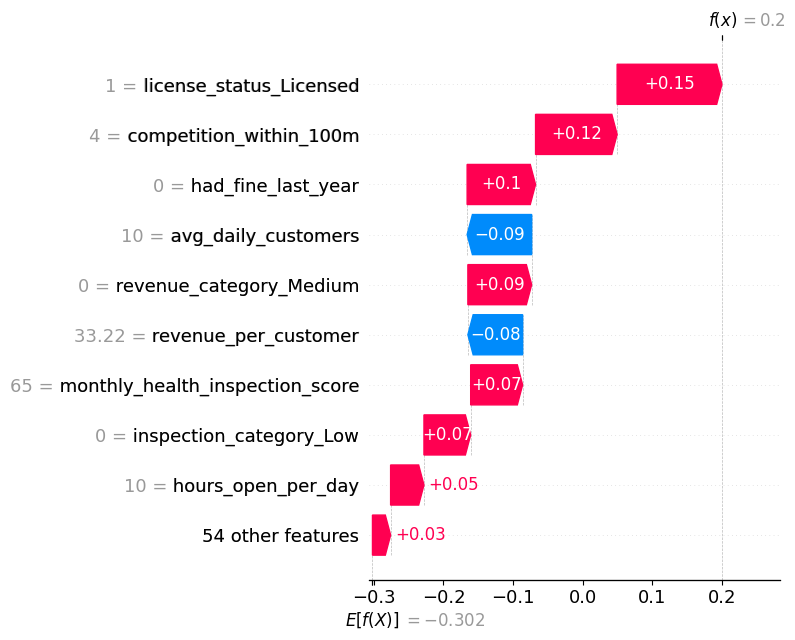

SHAP Waterfall Plot Saved:
C:/Users/HP/3D Objects/Desktop/College/College 5th Sem/Minor Project/Street-Vendor-Survival-Prediction/reports/figures/Explainability\shap_waterfall.png


In [24]:
plt.figure()
shap.plots.waterfall(sample_explanation[0], show=False)

plt.tight_layout()
waterfall_file = os.path.join(figure_path, "shap_waterfall.png")

plt.savefig(
    waterfall_file,
    dpi=300,
    bbox_inches="tight")
plt.show()
plt.close()

print("SHAP Waterfall Plot Saved:")
print(waterfall_file)

In [25]:
print("Phase 7 Explainability Completed Successfully")
print("\nGenerated Files:")
print("1. feature_importance.png")
print("2. shap_summary.png")
print("3. shap_bar.png")
print("4. shap_waterfall.png")
print("5. shap_feature_importance.csv")

Phase 7 Explainability Completed Successfully

Generated Files:
1. feature_importance.png
2. shap_summary.png
3. shap_bar.png
4. shap_waterfall.png
5. shap_feature_importance.csv
